# Relationships between climate modes and capacity factors

In [1]:
import xarray as xr
import numpy as np

from scipy.stats import pearsonr, spearmanr
import geopandas

import warnings

import string
letters = list(string.ascii_lowercase)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/conda/analysis3-26.05/lib/gdalplugins/../libgdal.so.36)
/g/data/w42/dr6273/apps/conda/envs/pangeo/lib/python3.10/site-packages/pyproj/../../.././libtiff.so.6: version `LIBTIFF_4.6.1' not found (required by /opt/c

In [2]:
%cd /g/data/w42/dr6273/work/seasonal_energy/
import functions as fn

/g/data/w42/dr6273/work/seasonal_energy


In [3]:
%load_ext autoreload
%autoreload 2

# Load data

#### Climate drivers

- 3 monthly mean for oceanic indices

In [4]:
def roll_3month(ds):
    """
    3 monthly mean
    """
    return ds.rolling(time=3).mean()

In [5]:
drivers_fp = "/g/data/w42/dr6273/work/data/"

In [6]:
nino34 = xr.open_zarr(
    drivers_fp + "hadisst/climate_modes/hadisst_nino34_1940-2023.zarr",
    consolidated=True
)["nino34_detrended"]

In [7]:
nino34 = roll_3month(nino34).compute()

In [8]:
dmi = xr.open_zarr(
    drivers_fp + "hadisst/climate_modes/hadisst_dmi_1940-2023.zarr",
    consolidated=True
)["dmi_detrended"]

In [9]:
dmi = roll_3month(dmi).compute()

In [10]:
sam = xr.open_zarr(
    drivers_fp + "era5/climate_modes/era5_sam_1940-2023.zarr",
    consolidated=True
)["sam_detrended"].compute()

Can't floor timestamps to the beginning of the month, so hack it and set Nino34 and DMI time to that of SAM

In [11]:
nino34["time"] = sam["time"]

In [12]:
dmi["time"] = sam["time"]

#### Wind and solar capacity factors

In [15]:
cf_wind = xr.open_zarr(
    "/scratch/dt6/dr6273/data/energy/wind_capacity_factor_van_der_Wiel_era5_monthly_1940-2023_detrended.zarr",
    consolidated=True
)["capacity_factor_detrended"].compute()

In [16]:
# Non-detrended mean
cf_wind_mean = xr.open_zarr(
    "/scratch/dt6/dr6273/data/energy/wind_capacity_factor_van_der_Wiel_era5_monthly_1940-2023.zarr",
    consolidated=True
)["capacity_factor"].mean("time").compute()

In [18]:
cf_solar = xr.open_zarr(
    "/scratch/dt6/dr6273/data/energy/solar_capacity_factor_van_der_Wiel_era5_monthly_1940-2023_detrended.zarr",
    consolidated=True
)["capacity_factor_detrended"].compute()

In [19]:
# Non-detrended mean
cf_solar_mean = xr.open_zarr(
    "/scratch/dt6/dr6273/data/energy/solar_capacity_factor_van_der_Wiel_era5_monthly_1940-2023.zarr",
    consolidated=True
)["capacity_factor"].mean("time").compute()

#### State mask
Generated here: https://github.com/dougrichardson/demand_model/blob/main/07_region_masks.ipynb

In [22]:
nem_mask = xr.open_dataset("/g/data/w42/dr6273/work/projects/Aus_energy/data/NEM_state_mask.nc").mask

#### Renewable Energy Zones

In [23]:
def get_REZ_mean(ds, gen_type, mask, region_code_name="SC2050"):
    """
    Compute values averaged for grid cells in each REZ
    
    ds: dataset of data to average
    gen_type: str, 'wind' or 'solar', used to set numeric codes for REZs to use
    mask: dataset of region mask
    region_code_name: str, append to 'region_code_' in ds e.g. 'SC2050'
    """
    if gen_type == "wind": 
        codes = [1, 3, 4]
    elif gen_type == "solar":
        codes = [2, 3]
    else:
        raise ValueError("Incorrect gen_type")
        
    da_list = []
    for region in mask["region"].values:
        m = mask.sel(region=region) # Mask for this region
        
        if m["region_code_"+region_code_name] in codes: # Skip regions without this gen_type
            d = ds.where(m, drop=True).mean(["lat", "lon"])
            d = d.expand_dims({"region": [region]})
            da_list.append(d)
        else:
            pass
        
    return xr.concat(da_list, dim="region")

In [24]:
rez_gpd = geopandas.read_file(
    "/g/data/w42/dr6273/work/projects/Aus_energy/data/resource_coded_Indicative_REZ_boundaries_2024_GIS_data.shp"
)

In [25]:
rez_mask = xr.open_dataset('/g/data/w42/dr6273/work/projects/Aus_energy/data/rez_2024_mask_era5_grid.nc')["REZ"]

## Relationships with capacity factors

In [31]:
def correlation_by_month(ds1, ds2):
    """
    Return dataset with correlations computed for each month
    
    ds1, ds2: datasets to correlate
    """
    cor_list = []
    pval_list = []
    for m in range(1, 13):
        ds1_m = fn.sel_month(ds1, m)
        ds2_m = fn.sel_month(ds2, m)

        _cor, _pval = fn.xr_spearmanr(ds1_m, ds2_m)

        _cor = _cor.expand_dims({"month": [m]})
        _pval = _pval.expand_dims({"month": [m]})

        cor_list.append(_cor)
        pval_list.append(_pval)
        
    return xr.concat(cor_list, dim="month"), xr.concat(pval_list, dim="month")

In [32]:
def get_correlation_by_month(cf_ds_dict, mode_dict, compute=False):
    """
    Compute and write, or load, correlation between capacity factors and modes.
    
    cf_ds_dict, mode_dict: dict of capacity factors and mode data.
    compute: bool, whether to compute or load.
    """
    import pickle
    
    fp = "/g/data/w42/dr6273/work/projects/Aus_energy/monthly_data/"
    
    if compute:
        cf_cor = {}
        cf_pval = {}
        
        for cf_ds, cf_name in zip(
            list(cf_ds_dict.values()),
            list(cf_ds_dict.keys())
        ):
            cf_cor[cf_name] = {}
            cf_pval[cf_name] = {}

            for mode_ds, mode_name in zip(
                list(mode_dict.values()),
                list(mode_dict.keys())
            ):
                cf_cor[cf_name][mode_name] = {}
                cf_pval[cf_name][mode_name] = {}
                
                cf_cor[cf_name][mode_name]["monthly"], cf_pval[cf_name][mode_name]["monthly"] = correlation_by_month(cf_ds, mode_ds)
                cf_cor[cf_name][mode_name]["annual"], cf_pval[cf_name][mode_name]["annual"] = fn.xr_spearmanr(cf_ds, mode_ds)
                
        with open(fp + "capacity_factor_climate_mode_correlation.pkl", "wb") as handle:
            pickle.dump(cf_cor, handle, protocol=pickle.HIGHEST_PROTOCOL)

        with open(fp + "capacity_factor_climate_mode_correlation_pval.pkl", "wb") as handle:
            pickle.dump(cf_pval, handle, protocol=pickle.HIGHEST_PROTOCOL)

        return cf_cor, cf_pval
    else:
        with open(fp + "capacity_factor_climate_mode_correlation.pkl", "rb") as handle:
            cor = pickle.load(handle)
        with open(fp + "capacity_factor_climate_mode_correlation_pval.pkl", "rb") as handle:
            pval = pickle.load(handle)
        return cor, pval

In [33]:
def adjust_lightness(color, amount=0.5):
    """
        Adjusts lightness of the given color by multiplying (1-luminosity) by the given amount.
        Input can be matplotlib color string, hex string, or RGB tuple.

        Examples:
        >> adjust_lightness('g', 0.3)
        >> adjust_lightness('#F034A3', 0.6)
        >> adjust_lightness((.3,.55,.1), 0.5)
        
        From: https://stackoverflow.com/a/49601444
    """
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

In [46]:
def rez_scatter(ax, lat_lon, cor_da, gen_type, mask, fill_rez=None, region_code_name="SC2050"):
    """
    Scatter REZ correlation
    
    ax: axes
    lat_lon: str, 'lat' or 'lon', or None, indicating which dimension to average over.
    cor_da, dataset, array of correlations
    gen_type: str, 'wind' or 'solar'
    mask: dataset of REZs
    fill_rez: list of str, indicating REZ IDs for which to plot filled markers
    region_code_name: str, append to 'region_code_' in ds e.g. 'SC2050'
    """
    on_c = "tab:blue"
    off_c = "tab:blue"
    ms = 20
    
    d = get_REZ_mean(cor_da, gen_type, mask)
    d_on = d.where(d["region_code_"+region_code_name] != 4, drop=True)
    d_off = d.where(d["region_code_"+region_code_name] == 4, drop=True)
    if lat_lon == "lon":
        ax.scatter(d_on.values, d_on.latitude.values, marker="s", color=on_c, s=ms, ec="white")
        ax.scatter(d_off.values, d_off.latitude.values, marker="x", color=off_c, s=ms, ec="white")
    elif lat_lon == "lat":
        ax.scatter(d_on.longitude.values, d_on.values, marker="s", color=on_c, s=ms, ec="white")
        ax.scatter(d_off.longitude.values, d_off.values, marker="x", color=off_c, s=ms, ec="white")
    else:
        ax.scatter(d_on.longitude.values, d_on.latitude.values, marker="o", color="None", ec="k", s=ms*1.5+0.9, lw=1, zorder=1)
        ax.scatter(d_off.longitude.values, d_off.latitude.values, marker="s", color="None", ec="k", s=ms*2.5+0.9, lw=1, zorder=1)
        
        ax.scatter(d_on.longitude.values, d_on.latitude.values, marker="o", color="None", ec=on_c, s=ms*1.5, lw=1, zorder=2)
        ax.scatter(d_off.longitude.values, d_off.latitude.values, marker="s", color="None", ec=off_c, s=ms*2.5, lw=1, zorder=2)
        
        if isinstance(fill_rez, list):
            for r in fill_rez:
                _d = d.sel(region=r)
                if _d["region_code_"+region_code_name] != 4:
                    ax.scatter(_d.longitude.values, _d.latitude.values, marker="o", color=on_c, s=ms*1.5, zorder=2)
                else:
                    ax.scatter(_d.longitude.values, _d.latitude.values, marker="s", color=off_c, s=ms*2.5, zorder=2)

In [35]:
%%time
# Computing this for the first time takes ~ 20 minutes
cf_cor, cf_pval = get_correlation_by_month(
    {"wind": cf_wind, "solar": cf_solar},
    {"SAM": sam, "ENSO": nino34, "IOD": dmi},
    compute=False
)

CPU times: user 23.9 ms, sys: 53.8 ms, total: 77.7 ms
Wall time: 255 ms


In [44]:
def _add_contour(ax, da, pvals):
    """ add pvalue contour """
    mask = pvals.astype(float)

    ax.contour(
        da[da.dims[1]],
        da[da.dims[0]],
        mask,
        levels=[0.5],
        colors="cyan",
        linewidths=1,
        zorder=10,
        transform=ccrs.PlateCarree()
    )

0.5940265262731599


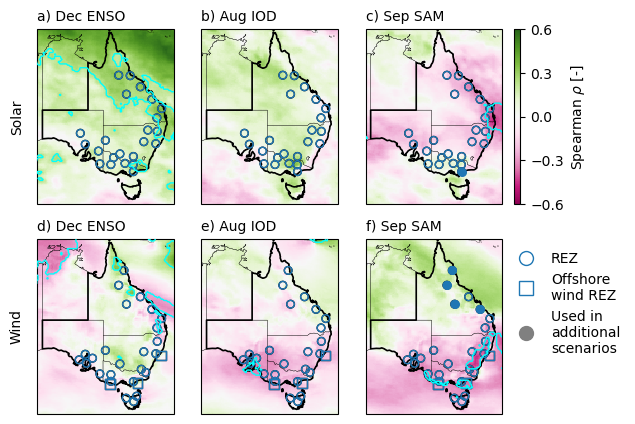

In [48]:
fig, ax = plt.subplots(2, 3, figsize=(6, 5), subplot_kw={"projection": ccrs.PlateCarree()})

from cartopy.io import shapereader
from shapely.ops import unary_union
wanted = {
    'Queensland',
    'New South Wales',
    'Australian Capital Territory',
    'Victoria',
    'South Australia',
    'Tasmania'
}

shp = shapereader.natural_earth(
    resolution='50m',
    category='cultural',
    name='admin_1_states_provinces'
)

reader = shapereader.Reader(shp)

geoms = [
    rec.geometry
    for rec in reader.records()
    if rec.attributes["admin"] == "Australia"
    and rec.attributes["name"] in wanted
]

# Merge the five polygons
merged = unary_union(geoms)

for a in ax.flatten():
    a.coastlines(lw=.2, rasterized=True)
    a.set_extent([128, 155.01, -10, -44])
    a.add_feature(
        cartopy.feature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces',
            scale='50m'
        ),
        facecolor='none',
        edgecolor='k',
        lw=.2,
        rasterized=True
    )

    # -------------------------------------------------------------------
    # Thick outline of QLD + NSW + VIC + SA + TAS
    # -------------------------------------------------------------------
    # Draw only the exterior boundary
    a.add_geometries(
        [merged.boundary],
        crs=ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='k',
        linewidth=1.2
    )
    
d1 = cf_cor["solar"]["ENSO"]["monthly"].sel(month=12)
pv1 = fn.fdr(cf_pval["solar"]["ENSO"]["monthly"].sel(month=12))

d2 = cf_cor["solar"]["IOD"]["monthly"].sel(month=8)
pv2 = fn.fdr(cf_pval["solar"]["IOD"]["monthly"].sel(month=8))

d3 = cf_cor["solar"]["SAM"]["monthly"].sel(month=9)
pv3 = fn.fdr(cf_pval["solar"]["SAM"]["monthly"].sel(month=9))

d4 = cf_cor["wind"]["ENSO"]["monthly"].sel(month=12)
pv4 = fn.fdr(cf_pval["wind"]["ENSO"]["monthly"].sel(month=12))

d5 = cf_cor["wind"]["IOD"]["monthly"].sel(month=8)
pv5 = fn.fdr(cf_pval["wind"]["IOD"]["monthly"].sel(month=8))

d6 = cf_cor["wind"]["SAM"]["monthly"].sel(month=9)
pv6 = fn.fdr(cf_pval["wind"]["SAM"]["monthly"].sel(month=9))

vmax = 0.6
vmin = vmax * -1

w_levels = np.arange(0.1, 1.1, 0.2)
s_levels = np.arange(0, 1.1, 0.05)
ws_linewidths = 1

p = d1.plot(ax=ax[0,0], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False)
_add_contour(ax[0,0], d1, pv1)
rez_scatter(ax[0,0], lat_lon=None, cor_da=d1, gen_type="solar", mask=rez_mask)

d2.plot(ax=ax[0,1], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False)
_add_contour(ax[0,1], d2, pv2)
rez_scatter(ax[0,1], lat_lon=None, cor_da=d2, gen_type="solar", mask=rez_mask)

d3.plot(ax=ax[0,2], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False)
_add_contour(ax[0,2], d3, pv3)
rez_scatter(ax[0,2], lat_lon=None, cor_da=d3, gen_type="solar", mask=rez_mask, fill_rez=["V5"])

d4.plot(ax=ax[1,0], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False)
_add_contour(ax[1,0], d4, pv4)
rez_scatter(ax[1,0], lat_lon=None, cor_da=d4, gen_type="wind", mask=rez_mask)

d5.plot(ax=ax[1,1], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False)
_add_contour(ax[1,1], d5, pv5)
rez_scatter(ax[1,1], lat_lon=None, cor_da=d5, gen_type="wind", mask=rez_mask)

d6.plot(ax=ax[1,2], vmin=vmin, vmax=vmax, cmap="PiYG", add_colorbar=False, zorder=0)
_add_contour(ax[1,2], d6, pv6)
rez_scatter(ax[1,2], lat_lon=None, cor_da=d6, gen_type="wind", mask=rez_mask, fill_rez=["Q1", "Q2", "Q5", "Q6"])

print(np.max([abs(ds).max().values for ds in [d1, d2, d3, d4, d5, d6]]))

for a in ax.flatten():
    a.set_title("")

ax[0,0].set_title("a) Dec ENSO", fontsize=10, loc="left")
ax[0,1].set_title("b) Aug IOD", fontsize=10, loc="left")
ax[0,2].set_title("c) Sep SAM", fontsize=10, loc="left")

ax[1,0].set_title("d) Dec ENSO", fontsize=10, loc="left")
ax[1,1].set_title("e) Aug IOD", fontsize=10, loc="left")
ax[1,2].set_title("f) Sep SAM", fontsize=10, loc="left")

ax[0,0].text(-0.2, 0.5, "Solar", va="center", rotation=90, transform=ax[0,0].transAxes)
ax[1,0].text(-0.2, 0.5, "Wind", va="center", rotation=90, transform=ax[1,0].transAxes)

cax1 = fig.add_axes([0.92, 0.53, 0.01, 0.35])
cbar1 = fig.colorbar(p, cax=cax1, ticks=np.arange(vmin, vmax + 0.01, vmax/2), orientation="vertical")
cbar1.ax.set_ylabel(r"Spearman $\rho$ [-]")

# REZ legend   
col1 = Line2D([0], [0], marker='o', linestyle="", markerfacecolor="None", color="tab:blue", markersize=10)
col2 = Line2D([0], [0], marker='s', linestyle="", markerfacecolor="None", color="tab:blue", markersize=10)
col3 = Line2D([0], [0], marker='o', linestyle="", markerfacecolor="gray", color="gray", markersize=10)
labels = ["REZ", "Offshore\nwind REZ", "Used in\nadditional\nscenarios"]

ax[-1,2].legend(
    [col1, col2, col3],
    labels,
    loc=(1.03, 0.3),
    ncol=1,
    frameon=False
)

plt.savefig("figures/capacity_factor_mode_correlation_months_resid_load.pdf", format="pdf", bbox_inches="tight")